In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 1000

# Генерируем признаки
weight = np.random.randint(50, 100, n)
time = np.random.randint(30, 120, n)
speed = np.random.uniform(8, 15, n).round(1)
age = np.random.randint(18, 65, n)
heart_rate = np.random.randint(120, 175, n)
height = np.random.randint(155, 195, n)

# Калории считаются по формуле с реальной зависимостью
calories = (0.6 * weight + 4.5 * time + 10 * speed - 0.3 * age + 
            0.5 * heart_rate + np.random.normal(0, 30, n)).astype(int)

synthetic = pd.DataFrame({
    'Gender': np.random.randint(0, 2, n),
    'Age': age,
    'Height(cm)': height,
    'Weight(kg)': weight,
    'BMI': (weight / ((height/100)**2)).round(1),
    'Running Time(min)': time,
    'Running Speed(km/h)': speed,
    'Distance(km)': (speed * time / 60).round(2),
    'Average Heart Rate': heart_rate,
    'Calories Burned': calories
})

# Объединяем старый датасет с новым
df = pd.concat([synthetic], ignore_index=True)
print(df.shape) 
print(df.head())
print(df.columns)

(1000, 10)
   Gender  Age  Height(cm)  Weight(kg)   BMI  Running Time(min)  \
0       0   32         172          88  29.7                 62   
1       1   43         171          78  26.7                 82   
2       0   54         184          64  18.9                 51   
3       0   38         193          92  24.7                 50   
4       1   48         167          57  20.4                 99   

   Running Speed(km/h)  Distance(km)  Average Heart Rate  Calories Burned  
0                  9.7         10.02                 129              522  
1                 13.4         18.31                 153              632  
2                 10.8          9.18                 144              446  
3                 12.2         10.17                 154              516  
4                 12.4         20.46                 135              625  
Index(['Gender', 'Age', 'Height(cm)', 'Weight(kg)', 'BMI', 'Running Time(min)',
       'Running Speed(km/h)', 'Distance(km)', 'Ave

Распределение целевой переменной 

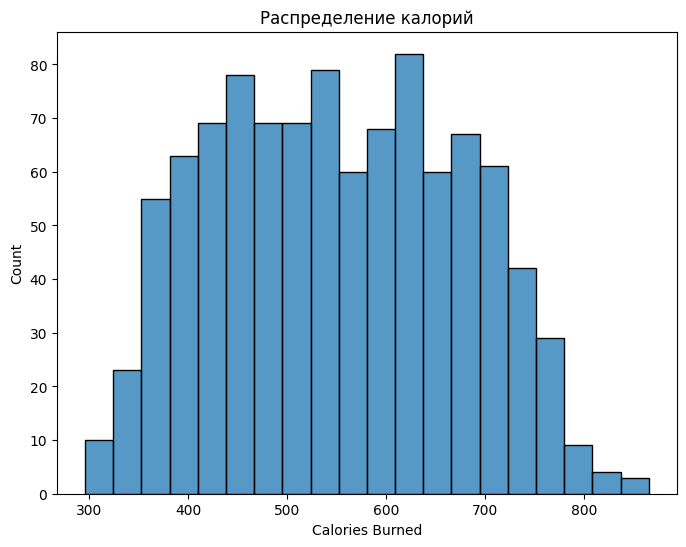

In [51]:
plt.figure(figsize=(8,6))
sns.histplot(df['Calories Burned'], bins=20)
plt.title('Распределение калорий')
plt.show()

<Axes: >

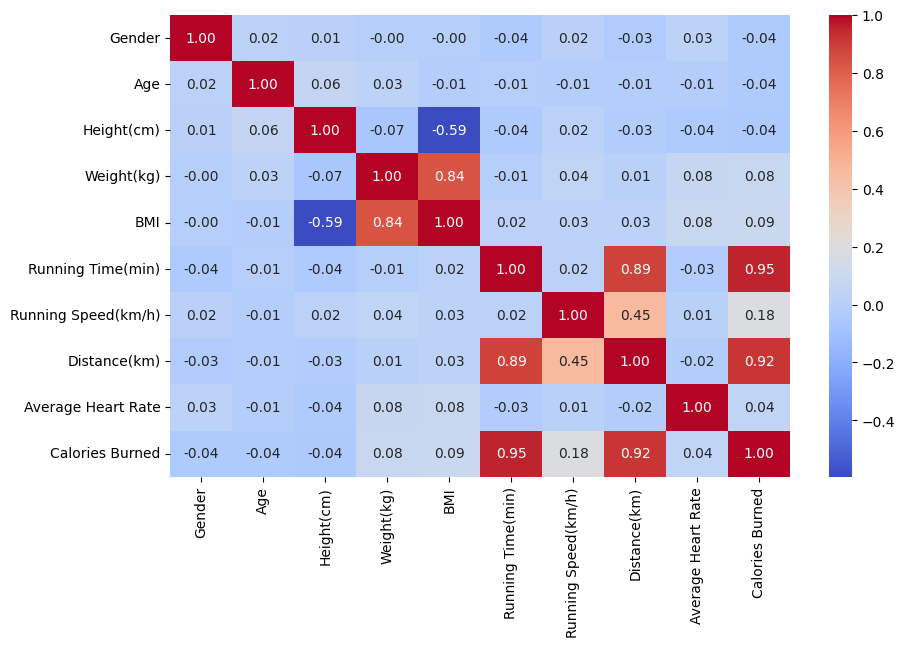

In [52]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')

Строим модель

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X=df.drop(columns=['Calories Burned'])
y=df['Calories Burned']
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')

Train: (800, 9)
Test: (200, 9)


Масштабирование признаков

In [54]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

poly=PolynomialFeatures(degree=2, include_bias=False)
X_train_poly=poly.fit_transform(X_train_scaled)
X_test_poly=poly.transform(X_test_scaled)



Обучаем и оцениваем модель 

In [55]:
#Линейная регрессия 
model=LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred=model.predict(X_test_scaled)

# Полиномиальная регрессия
model_poly=LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly=model_poly.predict(X_test_poly)

mae=mean_absolute_error(y_test, y_pred)
rmse=mean_squared_error(y_test, y_pred)**0.5
r2=r2_score(y_test, y_pred)

mae_poly=mean_absolute_error(y_test, y_pred_poly)
rmse_poly=mean_squared_error(y_test, y_pred_poly)**0.5
r2_poly=r2_score(y_test, y_pred_poly)

print('Линейная регрессия')
print(f'Mae: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.2f}')
print('Полиномиальная')
print(f'Mae: {mae_poly:.2f}')
print(f'RMSE: {rmse_poly:.2f}')
print(f'R2: {r2_poly:.2f}')






Линейная регрессия
Mae: 23.22
RMSE: 28.66
R2: 0.95
Полиномиальная
Mae: 23.22
RMSE: 28.65
R2: 0.95


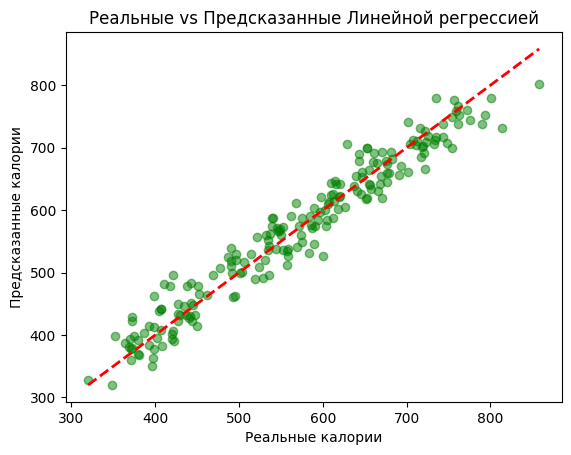

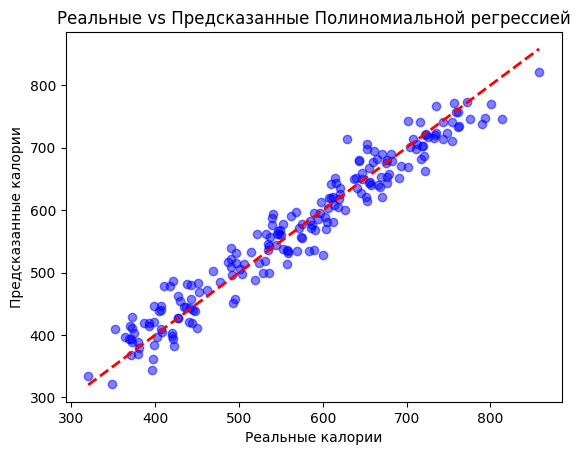

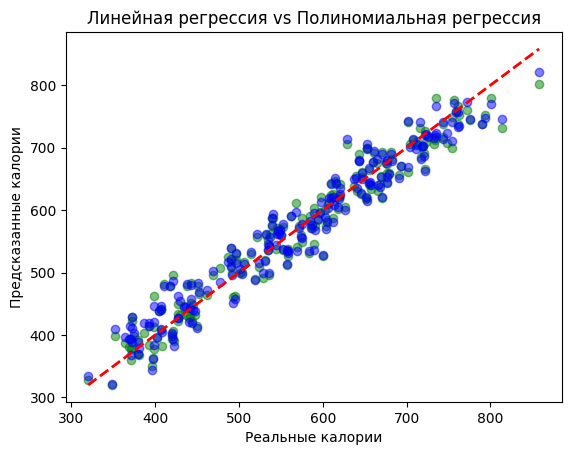

In [56]:
plt.Figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Реальные калории')
plt.ylabel('Предсказанные калории')
plt.title('Реальные vs Предсказанные Линейной регрессией')
plt.show()
plt.Figure(figsize=(8,6))
plt.scatter(y_test, y_pred_poly, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Реальные калории')
plt.ylabel('Предсказанные калории')
plt.title('Реальные vs Предсказанные Полиномиальной регрессией')
plt.show()

plt.Figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.scatter(y_test, y_pred_poly, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Реальные калории')
plt.ylabel('Предсказанные калории')
plt.title('Линейная регрессия vs Полиномиальная регрессия')
plt.show()


график ошибок

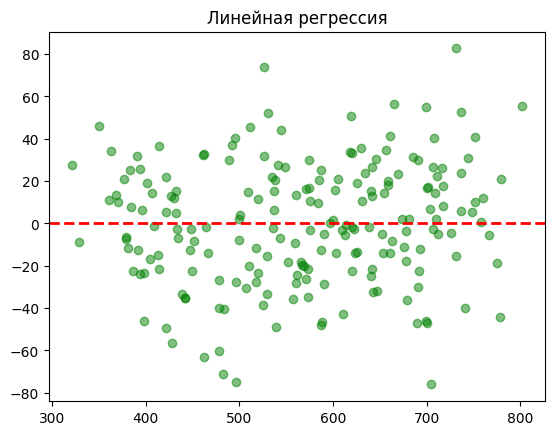

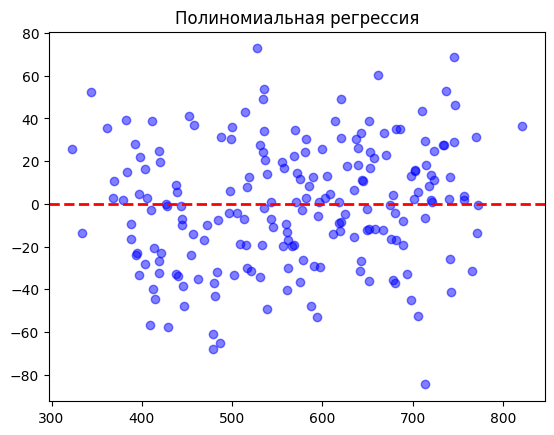

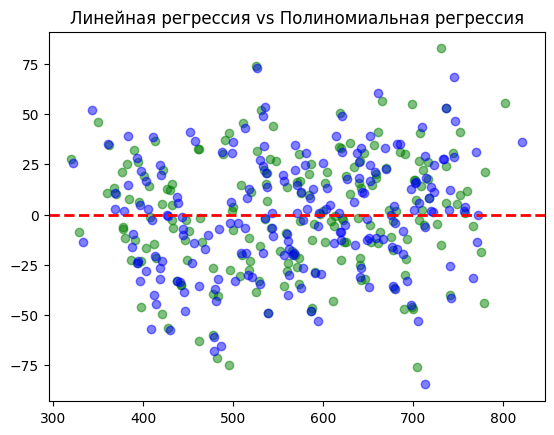

In [57]:
residuals=y_test-y_pred
residuals_poly=y_test-y_pred_poly
plt.Figure(figsize=(8,6))
plt.title('Линейная регрессия')
plt.scatter(y_pred, residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='r', linewidth=2, linestyle='--')
plt.show()
plt.Figure(figsize=(8,6))
plt.title('Полиномиальная регрессия')
plt.scatter(y_pred_poly, residuals_poly, alpha=0.5, color='blue')
plt.axhline(y=0, color='r', linewidth=2, linestyle='--')
plt.show()
plt.Figure(figsize=(8,6))
plt.title('Линейная регрессия vs Полиномиальная регрессия')
plt.scatter(y_pred, residuals, alpha=0.5, color='green')
plt.scatter(y_pred_poly, residuals_poly, alpha=0.5, color='blue')
plt.axhline(y=0, color='r', linewidth=2, linestyle='--')
plt.show()


важность признаков

/tmp/ipykernel_65056/2722959932.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Коэффициент', y='Признак', data=coefficient, palette='coolwarm')


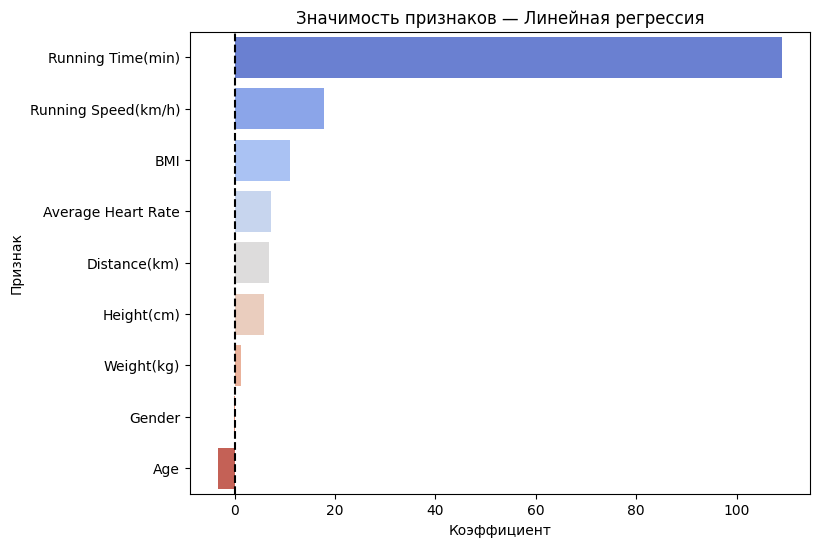

In [58]:
coefficient=pd.DataFrame({
    'Признак':X_train.columns,
    'Коэффициент': model.coef_
}).sort_values('Коэффициент', ascending=False )
poly_features = poly.get_feature_names_out(X_train.columns)
coefficient_poly=pd.DataFrame({
    'Признак':poly_features,
    'Коэффициент': model_poly.coef_
}).sort_values('Коэффициент', ascending=False )
plt.figure(figsize=(8, 6))
sns.barplot(x='Коэффициент', y='Признак', data=coefficient, palette='coolwarm')
plt.title('Значимость признаков — Линейная регрессия')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()


Проверяем переобучение 

In [59]:
y_pred_train=model.predict(X_train_scaled)
r2_train=r2_score(y_train, y_pred_train)
r2_test=r2_score(y_test, y_pred)
print('Линейная регрессия')
print(f'R2 Train: {r2_train:.2f}')
print(f'R2 Test: {r2_test:.2f}')

y_pred_poly_train=model_poly.predict(X_train_poly)
r2_poly_train=r2_score(y_train, y_pred_poly_train)
r2_poly_test=r2_score(y_test, y_pred_poly)
print('Полиномиальная регрессия')
print(f'R2 Train: {r2_poly_train:.2f}')
print(f'R2 Test: {r2_poly_test:.2f}')


Линейная регрессия
R2 Train: 0.94
R2 Test: 0.95
Полиномиальная регрессия
R2 Train: 0.95
R2 Test: 0.95


Проверяем одно предсказание вручную

In [60]:
sample=X_test_scaled[0]
real=y_test.iloc[0]
predicted=model.predict([sample])[0]

sample_poly=X_test_poly[0]
real=y_test.iloc[0]
predicted_poly=model_poly.predict([sample_poly])[0]

print('Линейная регрессия')
print(f'Реальные калории: {real}')
print(f'Предсказанные калории: {predicted:.2f}')
print(f'Ошибка: {abs(real-predicted):.2f}')
print('Полиномиальная регрессия')
print(f'Реальные калории: {real}')
print(f'Предсказанные калории: {predicted_poly:.2f}')
print(f'Ошибка: {abs(real-predicted_poly):.2f}')




Линейная регрессия
Реальные калории: 558
Предсказанные калории: 526.28
Ошибка: 31.72
Полиномиальная регрессия
Реальные калории: 558
Предсказанные калории: 533.94
Ошибка: 24.06


Итоговая таблица результатов

In [61]:
results=pd.DataFrame({
    'Метрики':['MAE','RMSE','R2'],
    'Значение':[
        f'{mean_absolute_error(y_test, y_pred):.2f}',
        f'{mean_squared_error(y_test, y_pred)**0.5:.2f}',
        f'{r2_score(y_test, y_pred):.2f}'
        
    ]
})
results_poly=pd.DataFrame({
    'Метрики':['MAE','RMSE','R2'],
    'Значение':[
        f'{mean_absolute_error(y_test, y_pred_poly):.2f}',
        f'{mean_squared_error(y_test, y_pred_poly)**0.5:.2f}',
        f'{r2_score(y_test, y_pred_poly):.2f}'
        
    ]
})
print('Линейная регрессия')
print(results)
print('Полиномиальная регрессия')
print(results_poly)

Линейная регрессия
  Метрики Значение
0     MAE    23.22
1    RMSE    28.66
2      R2     0.95
Полиномиальная регрессия
  Метрики Значение
0     MAE    23.22
1    RMSE    28.65
2      R2     0.95
